In [2]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import datetime
from pathlib import Path
from os import path

from rasterio.plot import plotting_extent
from matplotlib.colors import ListedColormap

import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from netCDF4 import Dataset
from wrf import getvar, get_cartopy, latlon_coords

In [ ]:
def plot_var(var, lats, lons, proj, title, cmap, levels=None,
             cbar_label="", shrink=0.6, figsize=(10, 8)):
    """
    Plot a variable on a map using Cartopy.
    """
    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=proj)

    contours = ax.contourf(lons, lats, var, cmap=cmap, levels=levels)

    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.STATES, linewidth=0.3)
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

    plt.colorbar(contours, ax=ax, label=cbar_label, shrink=shrink)
    plt.title(title)
    plt.show()
    return fig, ax

In [ ]:
plot_var(wrf_rh2, wrf_rh2_lats, wrf_rh2_lons, wrf_rh2_proj,
          "WRF 2-Meter Relative Humidity",
          cmap="BrBG", levels=range(0, 105, 5), cbar_label="Relative Humidity (%)")

# Files

In [3]:
# File paths
wrf_dir = "/Volumes/jchen/Share_Forecasts/WAC00WG-01/23050800/wrfout_d02_2023-05-08_03:00:00"
ai_bc_dir = "/Users/jchen/Anemoi/ignition/bc/08-10/20230508T00.nc"
ai_norway_dir = "/Users/jchen/Anemoi/ignition/norway/08-10/20230508T00.nc"

# Files
wrf = Dataset(wrf_dir)
ai_bc = Dataset(ai_bc_dir)
ai_norway = Dataset(ai_norway_dir)

wrf_xr = xr.open_dataset(wrf_dir)
ai_bc_xr = xr.open_dataset(ai_bc_dir)
ai_norway_xr = xr.open_dataset(ai_norway_dir)

# Relative Humidity

/Users/jchen/miniconda3/envs/geo/lib/python3.11/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


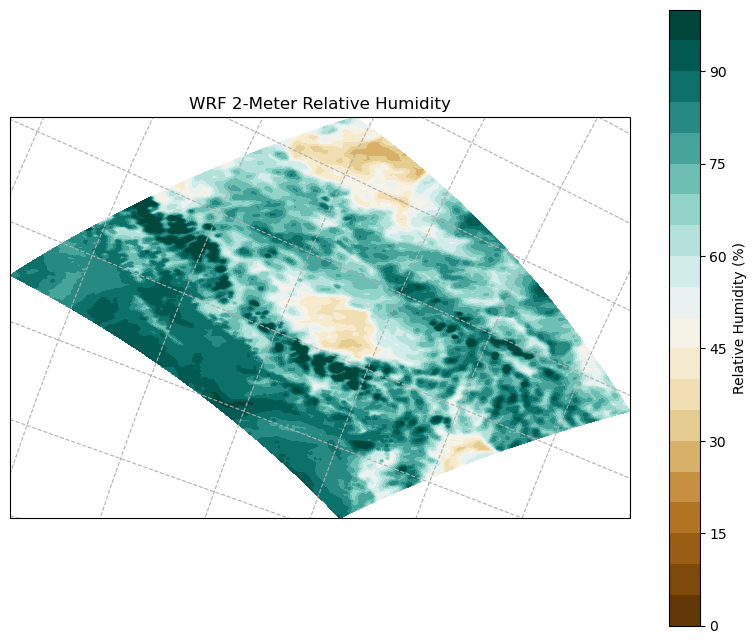

In [ ]:
# WRF
wrf_rh2 = getvar(wrf, "rh2", timeidx=0)
wrf_rh2_proj = get_cartopy(wrf_rh2)
wrf_rh2_fig = plt.figure(figsize=(10, 8))
wrf_rh2_ax = plt.axes(projection=wrf_rh2_proj)
wrf_rh2_lats, wrf_rh2_lons = latlon_coords(wrf_rh2)
wrf_rh2_contours = wrf_rh2_ax.contourf(wrf_rh2_lons, wrf_rh2_lats, wrf_rh2, 
                                       cmap="BrBG",
                                       levels = range(0, 105, 5))
wrf_rh2_ax.coastlines(linewidth=1.5)
wrf_rh2_ax.gridlines(linestyle="--")
plt.colorbar(wrf_rh2_contours, ax=wrf_rh2_ax, label="Relative Humidity (%)")
plt.title("WRF 2-Meter Relative Humidity")
plt.show()

# AI BC
ai_bc_rh2 = ai_bc_xr["rh2"].isel(time=0)
ai_bc_rh2_proj = get_cartopy(ai_bc_rh2)
ai_bc_rh2_fig = plt.figure(figsize=(10, 8))
ai_bc_rh2_ax = plt.axes(projection=ai_bc_rh2_proj)
ai_bc_rh2_lats, ai_bc_rh2_lons = latlon_coords(ai_bc_rh2)
ai_bc_rh2_contours = ai_bc_rh2_ax.contourf(ai_bc_rh2_lons, ai_bc_rh2_lats, ai_bc_rh2, 
                                          cmap="BrBG",
                                          levels = range(0, 105, 5))
ai_bc_rh2_ax.coastlines(linewidth=1.5)
ai_bc_rh2_ax.gridlines(linestyle="--")
plt.colorbar(ai_bc_rh2_contours, ax=ai_bc_rh2_ax, label="Relative Humidity (%)")
plt.title("AI BC 2-Meter Relative Humidity")
plt.show()

# AI Norway
ai_norway_rh2 = ai_norway_xr["rh2"].isel(time=0)
ai_norway_rh2_proj = get_cartopy(ai_norway_rh2)
ai_norway_rh2_fig = plt.figure(figsize=(10, 8))
ai_norway_rh2_ax = plt.axes(projection=ai_norway_rh2_proj)
ai_norway_rh2_lats, ai_norway_rh2_lons = latlon_coords(ai_norway_rh2)
ai_norway_rh2_contours = ai_norway_rh2_ax.contourf(ai_norway_rh2_lons, ai_norway_rh2_lats, ai_norway_rh2, 
                                                cmap="BrBG",
                                                levels = range(0, 105, 5))
ai_norway_rh2_ax.coastlines(linewidth=1.5)
ai_norway_rh2_ax.gridlines(linestyle="--")
plt.colorbar(ai_norway_rh2_contours, ax=ai_norway_rh2_ax, label="Relative Humidity (%)")
plt.title("AI Norway 2-Meter Relative Humidity")
plt.show()